# Food Safety Risk Analysis Using Python

This project uses Python to analyze food inspection data and identify patterns related to failed inspections, violation frequency, inspection risk levels, and corrective-action priorities.

The analysis focuses on:
- Which food business groups are most associated with failed inspections?
- Which groups have higher fail rates?
- Do high-risk inspections have more violations?
- How does inspection activity change over time?
- Which facilities should be prioritized for follow-up?

This project supports my transition into data analysis by connecting Python analysis skills with my background in food safety and quality.


## 1. Import Libraries & Settings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Chart display setting
plt.rcParams["figure.dpi"] = 100

In [2]:
# Color palette used across the notebook
colors = {
    "green": "#2E7D32",
    "red": "#C62828",
    "dark_red": "#B71C1C",
    "amber": "#F2A900",
    "orange": "#F57C00",
    "dark": "#263238",
    "grey": "#9CA3AF",
    "dark_grey": "#6B7280",
    "light_grey": "#D1D5DB"
}

# Colors for inspection result groups
result_colors = {
    "Compliant": colors["green"],
    "Non-Compliant": colors["red"],
    "Partially Compliant": colors["amber"],
    "Not Inspected": colors["grey"],
    "Inactive": colors["dark_grey"],
    "Unknown": colors["light_grey"],
    "Other": colors["light_grey"]
}

# Colors for inspection risk levels
risk_colors = {
    "High": colors["dark_red"],
    "Medium": colors["orange"],
    "Low": colors["grey"],
    "Unknown": colors["light_grey"]
}

# Colors for corrective-action priority levels
priority_colors = {
    "High Priority": colors["red"],
    "Medium Priority": colors["amber"],
    "Low Priority": colors["grey"]
}

## 2. Load Dataset


In [3]:
df = pd.read_csv("Chicago_Food_Inspections_2023_present.csv")

df.head()


,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2638882,Urban Playground,Urban Playground,3041983.0,Restaurant,Risk 1 (High),600 N MICHIGAN AVE,CHICAGO,IL,60611.0,23-06-26,License,Pass,NaN,41.892593,-87.624334,"\n, \n(41.89259322553828, -87.6243340479495)"
1,2638885,Urban Playground,Urban Playground,3041985.0,Restaurant,Risk 3 (Low),600 N MICHIGAN AVE,CHICAGO,IL,60611.0,23-06-26,License,Pass,NaN,41.892593,-87.624334,"\n, \n(41.89259322553828, -87.6243340479495)"
2,2638893,GOLDN BAKES,GOLDEN BAKES,3082356.0,Restaurant,Risk 1 (High),111 S MORGAN ST,CHICAGO,IL,60607.0,23-06-26,License,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.880048,-87.651832,"\n, \n(41.880047970125254, -87.65183157127098)"
3,2638855,SHINYA GRILL & BAR,SHINYA IZAKAYA GRILL & BAR,2913098.0,Restaurant,Risk 1 (High),2255 W NORTH AVE,CHICAGO,IL,60647.0,23-06-26,Complaint Re-Inspection,Pass,NaN,41.910251,-87.684549,"\n, \n(41.91025077942198, -87.68454945802267)"
4,2638852,WAVES BEACH BAR & GRILL LLC,WAVES BEACH BAR & GRILL,3090179.0,Restaurant,Risk 3 (Low),9801 S AVENUE G,CHICAGO,IL,60617.0,23-06-26,License,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.717720,-87.531508,"\n, \n(41.71772004446936, -87.53150811523324)"


In [4]:
print(f"The dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

The dataset contains 64,577 rows and 17 columns.


## 3. Data Understanding

Before cleaning the dataset, I explored its size, column structure, data types, missing values, date range, and the main categories available for inspection results, risk levels, facility types, and inspection types.


In [5]:
# View all column names in the dataset
for col in df.columns:
    print(col)

inspection_id
dba_name
aka_name
license_
facility_type
risk
address
city
state
zip
inspection_date
inspection_type
results
violations
latitude
longitude
location


In [6]:
# Check data types and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64577 entries, 0 to 64576
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inspection_id    64577 non-null  int64  
 1   dba_name         64577 non-null  object 
 2   aka_name         64514 non-null  object 
 3   license_         64575 non-null  float64
 4   facility_type    64207 non-null  object 
 5   risk             64559 non-null  object 
 6   address          64577 non-null  object 
 7   city             64520 non-null  object 
 8   state            64553 non-null  object 
 9   zip              64571 non-null  float64
 10  inspection_date  64577 non-null  object 
 11  inspection_type  64577 non-null  object 
 12  results          64577 non-null  object 
 13  violations       44132 non-null  object 
 14  latitude         64353 non-null  float64
 15  longitude        64353 non-null  float64
 16  location         64353 non-null  object 
dtypes: float64(4

In [7]:
# Check missing values
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values(by="Missing Values", ascending=False)

missing_summary


,Missing Values,Missing %
violations,20445,31.66
facility_type,370,0.57
longitude,224,0.35
location,224,0.35
latitude,224,0.35
aka_name,63,0.10
city,57,0.09
state,24,0.04
risk,18,0.03
zip,6,0.01


In [8]:
# Check inspection result categories
df["results"].value_counts(dropna=False)


results
Pass                    33874
Fail                    12082
Pass w/ Conditions       8203
No Entry                 4464
Out of Business          4444
Not Ready                1496
Business Not Located       14
Name: count, dtype: int64

In [9]:
# Check the distribution of inspection risk levels
df["risk"].value_counts(dropna=False)


risk
Risk 1 (High)      52288
Risk 2 (Medium)     9072
Risk 3 (Low)        3145
All                   54
NaN                   18
Name: count, dtype: int64

In [10]:
# Check the most common inspection types
df["inspection_type"].value_counts(dropna=False).head(15)


inspection_type
Canvass                                   32074
License                                    8718
Canvass Re-Inspection                      7977
Complaint                                  6245
Non-Inspection                             3679
Complaint Re-Inspection                    2555
License Re-Inspection                      1910
Short Form Complaint                       1221
Recent Inspection                           113
Suspected Food Poisoning                     52
Suspected Food Poisoning Re-inspection       17
Not Ready                                    10
Consultation                                  4
Special Events (Festivals)                    1
ASSESSMENT                                    1
Name: count, dtype: int64

In [11]:
# Check the most common facility types
df["facility_type"].value_counts(dropna=False).head(20)


facility_type
Restaurant                         45722
Grocery Store                       6063
School                              4016
Children's Services Facility        2328
Daycare Above and Under 2 Years      961
Bakery                               898
Long Term Care                       622
Mobile Food Preparer                 436
Daycare (2 - 6 Years)                425
Catering                             381
NaN                                  370
Liquor                               261
Hospital                             233
Shared Kitchen User (Long Term)      202
Golden Diner                         188
Shared Kitchen                       129
Special Event                         92
TAVERN                                64
CHARTER SCHOOL                        56
Mobile Food Dispenser                 47
Name: count, dtype: int64

In [12]:
# Check inspection date range
inspection_dates_check = pd.to_datetime(
    df["inspection_date"],
    format="%d-%m-%y",
    errors="coerce"
)

print("Earliest inspection date:", inspection_dates_check.min())
print("Latest inspection date:", inspection_dates_check.max())

# Check if any dates failed to convert
inspection_dates_check.isna().sum()


Earliest inspection date: 2023-01-03 00:00:00
Latest inspection date: 2026-06-23 00:00:00


np.int64(0)

### Initial Observations

The dataset contains inspection records with facility details, inspection dates, inspection types, inspection results, risk levels, violations, and location information.

The inspection results show that many inspections passed, but there are also failed inspections and inspections with conditions. The risk field is heavily concentrated in high-risk facilities, so risk level is important for analyzing violation patterns and corrective-action priorities.

The violations column contains many missing values, which is expected because not every inspection includes violations.


## 4. Data Cleaning & Feature Engineering

In this section, I created cleaner reporting fields that make the dataset easier to analyze. This included grouping inspection results, simplifying risk levels, identifying inspections with violations, counting violations, and grouping facility types into broader food business groups.


In [13]:
# Create a working copy of the dataset
df_clean = df.copy()

df_clean.head()

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2638882,Urban Playground,Urban Playground,3041983.0,Restaurant,Risk 1 (High),600 N MICHIGAN AVE,CHICAGO,IL,60611.0,23-06-26,License,Pass,NaN,41.892593,-87.624334,"\n, \n(41.89259322553828, -87.6243340479495)"
1,2638885,Urban Playground,Urban Playground,3041985.0,Restaurant,Risk 3 (Low),600 N MICHIGAN AVE,CHICAGO,IL,60611.0,23-06-26,License,Pass,NaN,41.892593,-87.624334,"\n, \n(41.89259322553828, -87.6243340479495)"
2,2638893,GOLDN BAKES,GOLDEN BAKES,3082356.0,Restaurant,Risk 1 (High),111 S MORGAN ST,CHICAGO,IL,60607.0,23-06-26,License,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.880048,-87.651832,"\n, \n(41.880047970125254, -87.65183157127098)"
3,2638855,SHINYA GRILL & BAR,SHINYA IZAKAYA GRILL & BAR,2913098.0,Restaurant,Risk 1 (High),2255 W NORTH AVE,CHICAGO,IL,60647.0,23-06-26,Complaint Re-Inspection,Pass,NaN,41.910251,-87.684549,"\n, \n(41.91025077942198, -87.68454945802267)"
4,2638852,WAVES BEACH BAR & GRILL LLC,WAVES BEACH BAR & GRILL,3090179.0,Restaurant,Risk 3 (Low),9801 S AVENUE G,CHICAGO,IL,60617.0,23-06-26,License,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.717720,-87.531508,"\n, \n(41.71772004446936, -87.53150811523324)"


In [14]:
# Convert inspection date to datetime format
df_clean["inspection_date"] = pd.to_datetime(
    df_clean["inspection_date"],
    format="%d-%m-%y",
    errors="coerce"
)

df_clean["inspection_date"].head()

0   2026-06-23
1   2026-06-23
2   2026-06-23
3   2026-06-23
4   2026-06-23
Name: inspection_date, dtype: datetime64[ns]

In [15]:
# Check inspection date range after conversion
print("Earliest inspection date:", df_clean["inspection_date"].min())
print("Latest inspection date:", df_clean["inspection_date"].max())

Earliest inspection date: 2023-01-03 00:00:00
Latest inspection date: 2026-06-23 00:00:00


In [16]:
# Check if any dates failed to convert
df_clean["inspection_date"].isna().sum()

np.int64(0)

In [17]:
# Remove extra spaces from text columns
text_columns = df_clean.select_dtypes(include="object").columns

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

### 4.1 Group Inspection Results

The original inspection result column includes several detailed categories. I grouped these into simpler compliance categories to make the analysis easier to read and interpret.

In [18]:
# Group inspection results into simpler compliance categories
result_map = {
    "Pass": "Compliant",
    "Pass w/ Conditions": "Partially Compliant",
    "Fail": "Non-Compliant",
    "No Entry": "Not Inspected",
    "Not Ready": "Not Inspected",
    "Business Not Located": "Not Inspected",
    "Out of Business": "Inactive"
}

df_clean["inspection_result_group"] = df_clean["results"].map(result_map).fillna("Other")

df_clean["inspection_result_group"].value_counts()

inspection_result_group
Compliant              33874
Non-Compliant          12082
Partially Compliant     8203
Not Inspected           5974
Inactive                4444
Name: count, dtype: int64

In [19]:
# Preview original and grouped inspection results
df_clean[["results", "inspection_result_group"]].head(10)

,results,inspection_result_group
0,Pass,Compliant
1,Pass,Compliant
2,Fail,Non-Compliant
3,Pass,Compliant
4,Fail,Non-Compliant
5,Fail,Non-Compliant
6,Fail,Non-Compliant
7,Pass w/ Conditions,Partially Compliant
8,Fail,Non-Compliant
9,Fail,Non-Compliant


### 4.2 Group Inspection Risk Levels

The original risk column includes detailed labels such as Risk 1 (High), Risk 2 (Medium), and Risk 3 (Low). I grouped these into simpler risk levels to make the analysis clearer and easier to visualize.

In [20]:
# Group inspection risk into simpler risk levels
risk_map = {
    "Risk 1 (High)": "High",
    "Risk 2 (Medium)": "Medium",
    "Risk 3 (Low)": "Low"
}

df_clean["inspection_risk_level"] = df_clean["risk"].map(risk_map).fillna("Unknown")

df_clean["inspection_risk_level"].value_counts()

inspection_risk_level
High       52288
Medium      9072
Low         3145
Unknown       72
Name: count, dtype: int64

In [21]:
# Create sort order for risk levels
risk_sort_map = {
    "High": 1,
    "Medium": 2,
    "Low": 3,
    "Unknown": 4
}

df_clean["inspection_risk_sort"] = df_clean["inspection_risk_level"].map(risk_sort_map)

df_clean[["risk", "inspection_risk_level", "inspection_risk_sort"]].head()

,risk,inspection_risk_level,inspection_risk_sort
0,Risk 1 (High),High,1
1,Risk 3 (Low),Low,3
2,Risk 1 (High),High,1
3,Risk 1 (High),High,1
4,Risk 3 (Low),Low,3


### 4.3 Create Violation Fields

The violations column contains detailed text when violations are recorded, and missing values when no violations are listed. I created new fields to identify whether an inspection had violations and to count how many violations were recorded.

In [22]:
# Create violation indicator and violation count
df_clean["has_violation"] = df_clean["violations"].notna()

df_clean["violation_count"] = df_clean["violations"].apply(
    lambda x: len(str(x).split("|")) if pd.notna(x) else 0
)

df_clean[["violations", "has_violation", "violation_count"]].head()

,violations,has_violation,violation_count
0,NaN,False,0
1,NaN,False,0
2,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,True,2
3,NaN,False,0
4,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,True,2


In [23]:
# Check how many inspections had violations
df_clean["has_violation"].value_counts()

has_violation
True     44132
False    20445
Name: count, dtype: int64

In [24]:
# Check violation count summary
violation_summary = df_clean["violation_count"].describe().round(2)

violation_summary

count    64577.00
mean         3.11
std          3.65
min          0.00
25%          0.00
50%          2.00
75%          5.00
max         40.00
Name: violation_count, dtype: float64

### 4.4 Create Date Fields

I created additional date fields from the inspection date to support time-based analysis, including year, month, and year-month fields.

In [25]:
# Create date fields for time-based analysis
df_clean["inspection_year"] = df_clean["inspection_date"].dt.year
df_clean["inspection_month"] = df_clean["inspection_date"].dt.month
df_clean["inspection_year_month"] = df_clean["inspection_date"].dt.to_period("M").astype(str)

df_clean[["inspection_date", "inspection_year", "inspection_month", "inspection_year_month"]].head()

,inspection_date,inspection_year,inspection_month,inspection_year_month
0,2026-06-23,2026,6,2026-06
1,2026-06-23,2026,6,2026-06
2,2026-06-23,2026,6,2026-06
3,2026-06-23,2026,6,2026-06
4,2026-06-23,2026,6,2026-06


In [26]:
# Check year-month values
df_clean["inspection_year_month"].value_counts().sort_index().head()

inspection_year_month
2023-01    1356
2023-02    1368
2023-03    1653
2023-04    1587
2023-05    1435
Name: count, dtype: int64

### 4.5 Group Facility Types

The original facility type column contains many detailed and inconsistent values. To make the analysis easier to understand, I grouped facility types into broader food business groups such as restaurants, supermarkets, bakeries, cafés, schools, childcare facilities, catering, and hospitality.

In [27]:
# Create broader food business groups from facility type
facility = df_clean["facility_type"].str.lower()

conditions = [
    facility.str.contains("restaurant|food service|diner|dining hall|food hall|tavern|bar|night club|hot dog", na=False),
    facility.str.contains("grocery|market|convenience|supermarket|liquor|wholesale|store|warehouse|retail food|retail sales|retail|general merchandise|food pantry|popcorn|distribution center", na=False),
    facility.str.contains("bakery|baker|dessert|sweet|ice cream|paleteria|candy|donut", na=False),
    facility.str.contains("coffee|cafe|tea|juice|beverage|smoothie|smoothies|shakes|nutrition|brewery|herbal drinks", na=False),
    facility.str.contains("school|shcool|education|public school|charter|cooking class|chef training", na=False),
    facility.str.contains("daycare|child|adult day service", na=False),
    facility.str.contains("catering|event|banquet", na=False),
    facility.str.contains("hotel|motel|hospitality|airport lounge|lounge|hostel", na=False),
    facility.str.contains("meat|poultry|seafood|fish|butcher|deli", na=False),
    facility.str.contains("shared kitchen|commissary|commisary|commisarry|kitchen", na=False),
    facility.str.contains("gas|gas station", na=False),
    facility.str.contains("mobile|vendor|truck|pop-up|pop up|kiosk", na=False),
    facility.str.contains("hospital|nursing|care|assisted living|supportive living|shelter|rehab center|youth housing", na=False),
    facility.str.contains("stadium|theater|theatre|music venue|venue|rooftop|roof top|roof tops|riverwalk|navy pier", na=False),
    facility.str.contains("church|vfw hall|not-for-profit club", na=False)
]

choices = [
    "Restaurants & Food Service",
    "Retail & Specialty Food Stores",
    "Bakeries, Sweets & Desserts",
    "Cafés & Beverage Shops",
    "Schools & Educational Facilities",
    "Nurseries & Childcare / Day Services",
    "Catering & Events",
    "Hotels & Hospitality",
    "Meat, Poultry & Seafood",
    "Central / Shared Kitchens",
    "Gas Stations / C-Stores",
    "Mobile / Temporary Food Vendors",
    "Healthcare / Residential Care",
    "Entertainment & Event Venues",
    "Community / Religious Facilities"
]

df_clean["food_business_group"] = np.select(
    conditions,
    choices,
    default="Other Food Facility"
)

df_clean.loc[df_clean["facility_type"].isna(), "food_business_group"] = "Unknown"

df_clean["food_business_group"].value_counts()

food_business_group
Restaurants & Food Service              46032
Retail & Specialty Food Stores           6451
Schools & Educational Facilities         4167
Nurseries & Childcare / Day Services     3860
Bakeries, Sweets & Desserts               946
Healthcare / Residential Care             944
Catering & Events                         592
Mobile / Temporary Food Vendors           562
Central / Shared Kitchens                 373
Unknown                                   370
Entertainment & Event Venues               97
Cafés & Beverage Shops                     49
Other Food Facility                        43
Gas Stations / C-Stores                    35
Hotels & Hospitality                       27
Meat, Poultry & Seafood                    18
Community / Religious Facilities           11
Name: count, dtype: int64

In [28]:
# Check facility types grouped as Other
df_clean.loc[
    df_clean["food_business_group"] == "Other Food Facility",
    "facility_type"
].value_counts().head(20)

facility_type
HERBALIFE                15
Other                     7
REGULATED BUSINESS        4
NAIL SALON                2
UNLICENSED FACILITY       2
GENERAL MECHANDISE        1
LIMITED BUSINESS          1
HERBALIFE/ZUMBA           1
HERBAL LIFE               1
COMMIASARY                1
GREENHOUSE                1
PACKAGED HEALTH FOODS     1
SUSHI COUNTER             1
FITNESS CENTER            1
ARCHDIOCESE               1
CULINARY CLASS ROOMS      1
NEWSSTAND                 1
HERBAL REMEDY             1
Name: count, dtype: int64

Note: Some low-frequency or unclear facility types remained under “Other Food Facility.” I kept these separate rather than forcing them into a category, because their meaning was not always clear from the original data.ies.

### 4.6 Create Flag Columns

I created numeric flag columns to make later calculations easier. These flags convert key categories into 1/0 values, which can be summed in groupby summaries.

In [29]:
# Create numeric flags for easier analysis
df_clean["failed_flag"] = (df_clean["inspection_result_group"] == "Non-Compliant").astype(int)
df_clean["passed_flag"] = (df_clean["inspection_result_group"] == "Compliant").astype(int)
df_clean["conditional_pass_flag"] = (df_clean["inspection_result_group"] == "Partially Compliant").astype(int)
df_clean["violation_flag"] = df_clean["has_violation"].astype(int)

df_clean[[
    "inspection_result_group",
    "failed_flag",
    "passed_flag",
    "conditional_pass_flag",
    "has_violation",
    "violation_flag",
    "violation_count"
]].head()

,inspection_result_group,failed_flag,passed_flag,conditional_pass_flag,has_violation,violation_flag,violation_count
0,Compliant,0,1,0,False,0,0
1,Compliant,0,1,0,False,0,0
2,Non-Compliant,1,0,0,True,1,2
3,Compliant,0,1,0,False,0,0
4,Non-Compliant,1,0,0,True,1,2


In [30]:
# Check cleaned dataset structure
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64577 entries, 0 to 64576
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   inspection_id            64577 non-null  int64         
 1   dba_name                 64577 non-null  object        
 2   aka_name                 64514 non-null  object        
 3   license_                 64575 non-null  float64       
 4   facility_type            64207 non-null  object        
 5   risk                     64559 non-null  object        
 6   address                  64577 non-null  object        
 7   city                     64520 non-null  object        
 8   state                    64553 non-null  object        
 9   zip                      64571 non-null  float64       
 10  inspection_date          64577 non-null  datetime64[ns]
 11  inspection_type          64577 non-null  object        
 12  results                  64577 n

In [31]:
# Preview cleaned dataset
df_clean.head()

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location,inspection_result_group,inspection_risk_level,inspection_risk_sort,has_violation,violation_count,inspection_year,inspection_month,inspection_year_month,food_business_group,failed_flag,passed_flag,conditional_pass_flag,violation_flag
0,2638882,Urban Playground,Urban Playground,3041983.0,Restaurant,Risk 1 (High),600 N MICHIGAN AVE,CHICAGO,IL,60611.0,2026-06-23,License,Pass,NaN,41.892593,-87.624334,", \n(41.89259322553828, -87.6243340479495)",Compliant,High,1,False,0,2026,6,2026-06,Restaurants & Food Service,0,1,0,0
1,2638885,Urban Playground,Urban Playground,3041985.0,Restaurant,Risk 3 (Low),600 N MICHIGAN AVE,CHICAGO,IL,60611.0,2026-06-23,License,Pass,NaN,41.892593,-87.624334,", \n(41.89259322553828, -87.6243340479495)",Compliant,Low,3,False,0,2026,6,2026-06,Restaurants & Food Service,0,1,0,0
2,2638893,GOLDN BAKES,GOLDEN BAKES,3082356.0,Restaurant,Risk 1 (High),111 S MORGAN ST,CHICAGO,IL,60607.0,2026-06-23,License,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.880048,-87.651832,", \n(41.880047970125254, -87.65183157127098)",Non-Compliant,High,1,True,2,2026,6,2026-06,Restaurants & Food Service,1,0,0,1
3,2638855,SHINYA GRILL & BAR,SHINYA IZAKAYA GRILL & BAR,2913098.0,Restaurant,Risk 1 (High),2255 W NORTH AVE,CHICAGO,IL,60647.0,2026-06-23,Complaint Re-Inspection,Pass,NaN,41.910251,-87.684549,", \n(41.91025077942198, -87.68454945802267)",Compliant,High,1,False,0,2026,6,2026-06,Restaurants & Food Service,0,1,0,0
4,2638852,WAVES BEACH BAR & GRILL LLC,WAVES BEACH BAR & GRILL,3090179.0,Restaurant,Risk 3 (Low),9801 S AVENUE G,CHICAGO,IL,60617.0,2026-06-23,License,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.717720,-87.531508,", \n(41.71772004446936, -87.53150811523324)",Non-Compliant,Low,3,True,2,2026,6,2026-06,Restaurants & Food Service,1,0,0,1


## 5. Exploratory Data Analysis

In this section, I explored inspection volume, compliance results, violation patterns, risk levels, and trends over time to understand where food safety issues are most concentrated.

### 5.1 Food Business Group Distribution

I started by checking how inspections are distributed across the broader food business groups created during data cleaning.

In [32]:
# Summarize inspections by food business group
food_group_summary = (
    df_clean["food_business_group"]
    .value_counts()
    .reset_index()
)

food_group_summary.columns = ["food_business_group", "inspection_count"]

food_group_summary["percentage"] = (
    food_group_summary["inspection_count"] / len(df_clean) * 100
).round(2)

food_group_summary.head(10)

,food_business_group,inspection_count,percentage
0,Restaurants & Food Service,46032,71.28
1,Retail & Specialty Food Stores,6451,9.99
2,Schools & Educational Facilities,4167,6.45
3,Nurseries & Childcare / Day Services,3860,5.98
4,"Bakeries, Sweets & Desserts",946,1.46
5,Healthcare / Residential Care,944,1.46
6,Catering & Events,592,0.92
7,Mobile / Temporary Food Vendors,562,0.87
8,Central / Shared Kitchens,373,0.58
9,Unknown,370,0.57


In [33]:
# Create a readable display table
food_group_summary_display = food_group_summary.rename(columns={
    "food_business_group": "Food Business Group",
    "inspection_count": "Inspection Count",
    "percentage": "Percentage (%)"
})

food_group_summary_display.head(10)

,Food Business Group,Inspection Count,Percentage (%)
0,Restaurants & Food Service,46032,71.28
1,Retail & Specialty Food Stores,6451,9.99
2,Schools & Educational Facilities,4167,6.45
3,Nurseries & Childcare / Day Services,3860,5.98
4,"Bakeries, Sweets & Desserts",946,1.46
5,Healthcare / Residential Care,944,1.46
6,Catering & Events,592,0.92
7,Mobile / Temporary Food Vendors,562,0.87
8,Central / Shared Kitchens,373,0.58
9,Unknown,370,0.57


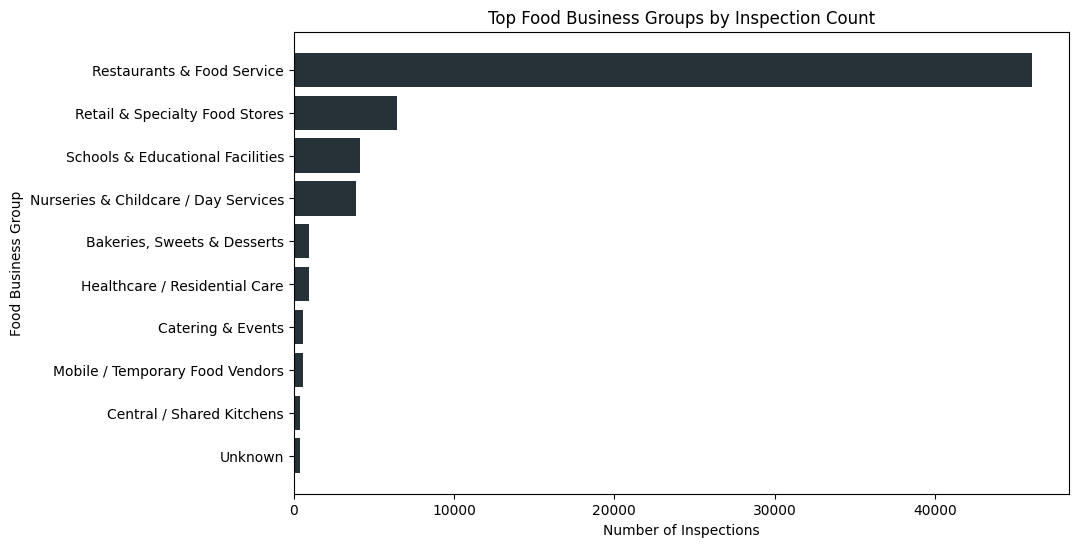

In [34]:
# Show top food business groups by inspection count
top_food_groups = food_group_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_food_groups["food_business_group"],
    top_food_groups["inspection_count"],
    color=colors["dark"]
)

plt.gca().invert_yaxis()
plt.title("Top Food Business Groups by Inspection Count")
plt.xlabel("Number of Inspections")
plt.ylabel("Food Business Group")
plt.show()

Restaurants and food service businesses represented the largest share of inspections. This is expected because restaurants are one of the most common food-related facility types and are inspected frequently. Reviewing the distribution first helps give context before comparing failures, violations, and risk levels.

### 5.2 Inspection Results Distribution

I analyzed the grouped inspection results to understand the overall compliance status of inspections.

In [35]:
# Summarize inspection results
result_summary = (
    df_clean["inspection_result_group"]
    .value_counts()
    .reset_index()
)

result_summary.columns = ["inspection_result_group", "inspection_count"]

result_summary["percentage"] = (
    result_summary["inspection_count"] / len(df_clean) * 100
).round(2)

result_summary

,inspection_result_group,inspection_count,percentage
0,Compliant,33874,52.46
1,Non-Compliant,12082,18.71
2,Partially Compliant,8203,12.70
3,Not Inspected,5974,9.25
4,Inactive,4444,6.88


In [36]:
# Create a readable display table
result_summary_display = result_summary.rename(columns={
    "inspection_result_group": "Inspection Result Group",
    "inspection_count": "Inspection Count",
    "percentage": "Percentage (%)"
})

result_summary_display

,Inspection Result Group,Inspection Count,Percentage (%)
0,Compliant,33874,52.46
1,Non-Compliant,12082,18.71
2,Partially Compliant,8203,12.70
3,Not Inspected,5974,9.25
4,Inactive,4444,6.88


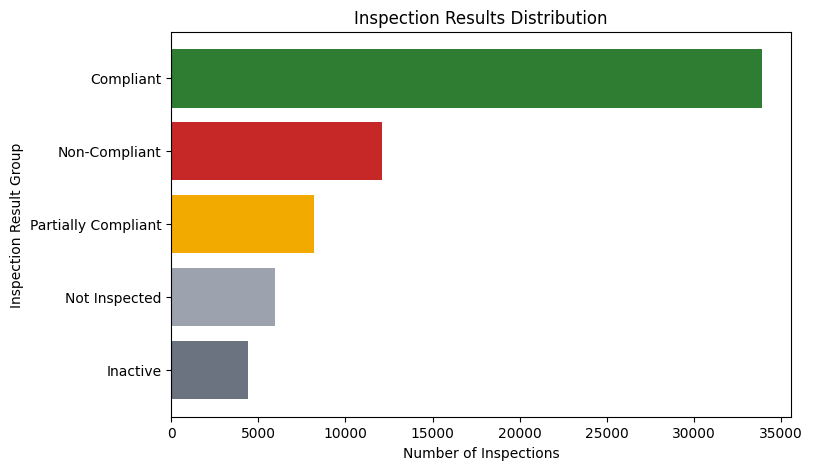

In [37]:
# Inspection results distribution chart
bar_colors = result_summary["inspection_result_group"].map(result_colors)

plt.figure(figsize=(8, 5))
plt.barh(
    result_summary["inspection_result_group"],
    result_summary["inspection_count"],
    color=bar_colors
)

plt.gca().invert_yaxis()
plt.title("Inspection Results Distribution")
plt.xlabel("Number of Inspections")
plt.ylabel("Inspection Result Group")
plt.show()

Most inspections were classified as compliant. However, non-compliant and partially compliant inspections still represented a meaningful portion of the dataset. This makes it useful to continue the analysis by looking at failure rates, violations, and risk levels.

### 5.3 Pass and Fail Rate Summary

I calculated key compliance rates to summarize the overall inspection performance, including pass rate, fail rate, and conditional pass rate.

In [38]:
# Calculate inspection result totals
total_inspections = len(df_clean)

passed_inspections = df_clean["passed_flag"].sum()
failed_inspections = df_clean["failed_flag"].sum()
conditional_pass_inspections = df_clean["conditional_pass_flag"].sum()

pass_rate = passed_inspections / total_inspections * 100
fail_rate = failed_inspections / total_inspections * 100
conditional_pass_rate = conditional_pass_inspections / total_inspections * 100

print(f"Total inspections: {total_inspections:,}")
print(f"Passed inspections: {passed_inspections:,} ({pass_rate:.2f}%)")
print(f"Failed inspections: {failed_inspections:,} ({fail_rate:.2f}%)")
print(f"Conditional pass inspections: {conditional_pass_inspections:,} ({conditional_pass_rate:.2f}%)")

Total inspections: 64,577
Passed inspections: 33,874 (52.46%)
Failed inspections: 12,082 (18.71%)
Conditional pass inspections: 8,203 (12.70%)


In [39]:
#Create compliance rate summary table
compliance_summary = pd.DataFrame({
    "Metric": [
        "Total Inspections",
        "Passed Inspections",
        "Failed Inspections",
        "Conditional Pass Inspections",
        "Pass Rate (%)",
        "Fail Rate (%)",
        "Conditional Pass Rate (%)"
    ],
    "Value": [
        total_inspections,
        passed_inspections,
        failed_inspections,
        conditional_pass_inspections,
        round(pass_rate, 2),
        round(fail_rate, 2),
        round(conditional_pass_rate, 2)
    ]
})

compliance_summary

,Metric,Value
0,Total Inspections,64577.00
1,Passed Inspections,33874.00
2,Failed Inspections,12082.00
3,Conditional Pass Inspections,8203.00
4,Pass Rate (%),52.46
5,Fail Rate (%),18.71
6,Conditional Pass Rate (%),12.70


The pass rate provides a high-level view of compliance performance, while the fail rate and conditional pass rate show where follow-up may be needed. Although more than half of inspections passed, failed and conditional pass results still represent important areas for food safety monitoring.

### 5.4 Failed Inspections by Food Business Group

I summarized inspection results by food business group to identify which groups had the highest number of failed inspections.

In [40]:
# Summarize inspection results by food business group
business_result_summary = df_clean.groupby("food_business_group").agg(
    total_inspections=("inspection_id", "count"),
    failed_inspections=("failed_flag", "sum"),
    passed_inspections=("passed_flag", "sum")
).reset_index()

business_result_summary["fail_rate"] = (
    business_result_summary["failed_inspections"] / business_result_summary["total_inspections"] * 100
).round(2)

business_result_summary["pass_rate"] = (
    business_result_summary["passed_inspections"] / business_result_summary["total_inspections"] * 100
).round(2)

business_result_summary = business_result_summary.sort_values(
    by="failed_inspections",
    ascending=False
)

business_result_summary.head(10)

,food_business_group,total_inspections,failed_inspections,passed_inspections,fail_rate,pass_rate
13,Restaurants & Food Service,46032,8381,23258,18.21,50.53
14,Retail & Specialty Food Stores,6451,1311,3194,20.32,49.51
15,Schools & Educational Facilities,4167,1032,2650,24.77,63.59
11,Nurseries & Childcare / Day Services,3860,674,2596,17.46,67.25
7,Healthcare / Residential Care,944,207,558,21.93,59.11
0,"Bakeries, Sweets & Desserts",946,186,494,19.66,52.22
10,Mobile / Temporary Food Vendors,562,101,381,17.97,67.79
2,Catering & Events,592,72,305,12.16,51.52
3,Central / Shared Kitchens,373,40,254,10.72,68.10
16,Unknown,370,19,54,5.14,14.59


In [41]:
# Keep groups with enough inspection records for meaningful comparison
business_result_filtered = business_result_summary[
    (business_result_summary["total_inspections"] >= 100) &
    (~business_result_summary["food_business_group"].isin(["Unknown", "Other Food Facility"]))
].copy()

business_result_filtered.head(10)

,food_business_group,total_inspections,failed_inspections,passed_inspections,fail_rate,pass_rate
13,Restaurants & Food Service,46032,8381,23258,18.21,50.53
14,Retail & Specialty Food Stores,6451,1311,3194,20.32,49.51
15,Schools & Educational Facilities,4167,1032,2650,24.77,63.59
11,Nurseries & Childcare / Day Services,3860,674,2596,17.46,67.25
7,Healthcare / Residential Care,944,207,558,21.93,59.11
0,"Bakeries, Sweets & Desserts",946,186,494,19.66,52.22
10,Mobile / Temporary Food Vendors,562,101,381,17.97,67.79
2,Catering & Events,592,72,305,12.16,51.52
3,Central / Shared Kitchens,373,40,254,10.72,68.10


In [42]:
#readable display table
business_result_display = business_result_filtered.rename(columns={
    "food_business_group": "Food Business Group",
    "total_inspections": "Total Inspections",
    "failed_inspections": "Failed Inspections",
    "passed_inspections": "Passed Inspections",
    "fail_rate": "Fail Rate (%)",
    "pass_rate": "Pass Rate (%)"
})

business_result_display.head(10)

,Food Business Group,Total Inspections,Failed Inspections,Passed Inspections,Fail Rate (%),Pass Rate (%)
13,Restaurants & Food Service,46032,8381,23258,18.21,50.53
14,Retail & Specialty Food Stores,6451,1311,3194,20.32,49.51
15,Schools & Educational Facilities,4167,1032,2650,24.77,63.59
11,Nurseries & Childcare / Day Services,3860,674,2596,17.46,67.25
7,Healthcare / Residential Care,944,207,558,21.93,59.11
0,"Bakeries, Sweets & Desserts",946,186,494,19.66,52.22
10,Mobile / Temporary Food Vendors,562,101,381,17.97,67.79
2,Catering & Events,592,72,305,12.16,51.52
3,Central / Shared Kitchens,373,40,254,10.72,68.10


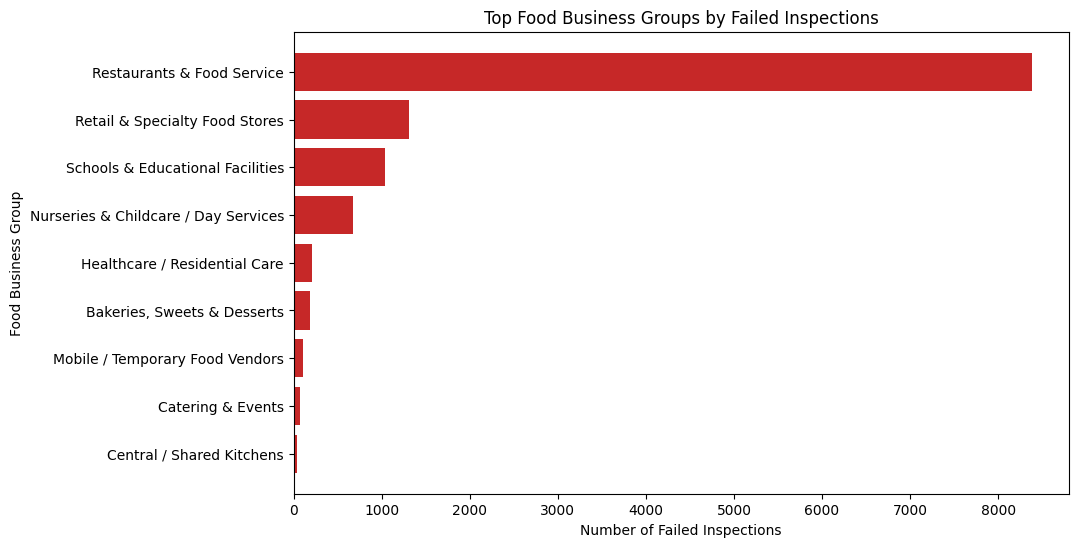

In [43]:
# top food business groups by failed inspections chart
top_failed_groups = business_result_filtered.sort_values(
    by="failed_inspections",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_failed_groups["food_business_group"],
    top_failed_groups["failed_inspections"],
    color=colors["red"]
)

plt.gca().invert_yaxis()
plt.title("Top Food Business Groups by Failed Inspections")
plt.xlabel("Number of Failed Inspections")
plt.ylabel("Food Business Group")
plt.show()

Restaurants and food service businesses had the highest number of failed inspections. This is partly because they also represented the largest inspection volume, so the next step is to review fail rate as a proportional measure.

### 5.5 Fail Rate by Food Business Group

After reviewing failed inspection counts, I compared fail rates by food business group. This helps identify groups with higher proportional non-compliance, regardless of their total inspection volume.

In [44]:
# food business groups with the highest fail rate
top_fail_rate_groups = business_result_filtered.sort_values(
    by="fail_rate",
    ascending=False
).head(10)

top_fail_rate_groups

,food_business_group,total_inspections,failed_inspections,passed_inspections,fail_rate,pass_rate
15,Schools & Educational Facilities,4167,1032,2650,24.77,63.59
7,Healthcare / Residential Care,944,207,558,21.93,59.11
14,Retail & Specialty Food Stores,6451,1311,3194,20.32,49.51
0,"Bakeries, Sweets & Desserts",946,186,494,19.66,52.22
13,Restaurants & Food Service,46032,8381,23258,18.21,50.53
10,Mobile / Temporary Food Vendors,562,101,381,17.97,67.79
11,Nurseries & Childcare / Day Services,3860,674,2596,17.46,67.25
2,Catering & Events,592,72,305,12.16,51.52
3,Central / Shared Kitchens,373,40,254,10.72,68.10


In [45]:
#Create a readable display table
top_fail_rate_display = top_fail_rate_groups.rename(columns={
    "food_business_group": "Food Business Group",
    "total_inspections": "Total Inspections",
    "failed_inspections": "Failed Inspections",
    "passed_inspections": "Passed Inspections",
    "fail_rate": "Fail Rate (%)",
    "pass_rate": "Pass Rate (%)"
})

top_fail_rate_display

,Food Business Group,Total Inspections,Failed Inspections,Passed Inspections,Fail Rate (%),Pass Rate (%)
15,Schools & Educational Facilities,4167,1032,2650,24.77,63.59
7,Healthcare / Residential Care,944,207,558,21.93,59.11
14,Retail & Specialty Food Stores,6451,1311,3194,20.32,49.51
0,"Bakeries, Sweets & Desserts",946,186,494,19.66,52.22
13,Restaurants & Food Service,46032,8381,23258,18.21,50.53
10,Mobile / Temporary Food Vendors,562,101,381,17.97,67.79
11,Nurseries & Childcare / Day Services,3860,674,2596,17.46,67.25
2,Catering & Events,592,72,305,12.16,51.52
3,Central / Shared Kitchens,373,40,254,10.72,68.10


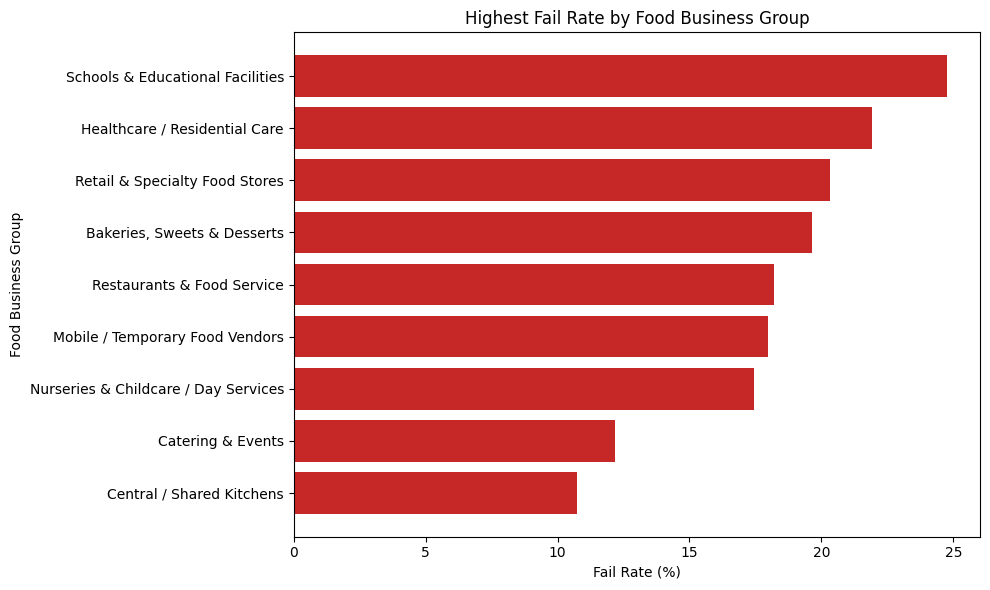

In [46]:
# Highest fail rate by food business group
plt.figure(figsize=(10, 6))
plt.barh(
    top_fail_rate_groups["food_business_group"],
    top_fail_rate_groups["fail_rate"],
    color=colors["red"]
)

plt.gca().invert_yaxis()
plt.title("Highest Fail Rate by Food Business Group")
plt.xlabel("Fail Rate (%)")
plt.ylabel("Food Business Group")

plt.tight_layout()
plt.show()


Although restaurants had the highest number of failed inspections, fail rate gives a more proportional view of compliance performance. This helps highlight business groups that may have a higher share of failed inspections even if their total inspection volume is lower.

### 5.6 Violations by Risk Level

I analyzed violations by inspection risk level to understand whether higher-risk facilities had more violations or higher violation rates.

In [47]:
# Summarize violations by risk level
risk_summary = df_clean.groupby("inspection_risk_level").agg(
    total_inspections=("inspection_id", "count"),
    failed_inspections=("failed_flag", "sum"),
    inspections_with_violations=("violation_flag", "sum"),
    total_violations=("violation_count", "sum")
).reset_index()

risk_summary

,inspection_risk_level,total_inspections,failed_inspections,inspections_with_violations,total_violations
0,High,52288,9894,36986,170579
1,Low,3145,568,1325,5513
2,Medium,9072,1618,5819,24860
3,Unknown,72,2,2,10


In [48]:
# Calculate fail rate, violation rate, and average violations
risk_summary["fail_rate"] = (
    risk_summary["failed_inspections"] / risk_summary["total_inspections"] * 100
).round(2)

risk_summary["violation_rate"] = (
    risk_summary["inspections_with_violations"] / risk_summary["total_inspections"] * 100
).round(2)

risk_summary["avg_violations_per_inspection"] = (
    risk_summary["total_violations"] / risk_summary["total_inspections"]
).round(2)

risk_summary

,inspection_risk_level,total_inspections,failed_inspections,inspections_with_violations,total_violations,fail_rate,violation_rate,avg_violations_per_inspection
0,High,52288,9894,36986,170579,18.92,70.74,3.26
1,Low,3145,568,1325,5513,18.06,42.13,1.75
2,Medium,9072,1618,5819,24860,17.84,64.14,2.74
3,Unknown,72,2,2,10,2.78,2.78,0.14


In [49]:
# Sort risk levels in a logical order
risk_sort = {
    "High": 1,
    "Medium": 2,
    "Low": 3,
    "Unknown": 4
}

risk_summary["risk_sort"] = risk_summary["inspection_risk_level"].map(risk_sort)

risk_summary = risk_summary.sort_values("risk_sort")

risk_summary


,inspection_risk_level,total_inspections,failed_inspections,inspections_with_violations,total_violations,fail_rate,violation_rate,avg_violations_per_inspection,risk_sort
0,High,52288,9894,36986,170579,18.92,70.74,3.26,1
2,Medium,9072,1618,5819,24860,17.84,64.14,2.74,2
1,Low,3145,568,1325,5513,18.06,42.13,1.75,3
3,Unknown,72,2,2,10,2.78,2.78,0.14,4


In [50]:
# Remove Unknown from charts only
risk_summary_chart = risk_summary[
    risk_summary["inspection_risk_level"] != "Unknown"
].copy()

risk_summary_chart

,inspection_risk_level,total_inspections,failed_inspections,inspections_with_violations,total_violations,fail_rate,violation_rate,avg_violations_per_inspection,risk_sort
0,High,52288,9894,36986,170579,18.92,70.74,3.26,1
2,Medium,9072,1618,5819,24860,17.84,64.14,2.74,2
1,Low,3145,568,1325,5513,18.06,42.13,1.75,3


In [51]:
# Create a readable display table
risk_summary_display = risk_summary.rename(columns={
    "inspection_risk_level": "Risk Level",
    "total_inspections": "Total Inspections",
    "failed_inspections": "Failed Inspections",
    "inspections_with_violations": "Inspections with Violations",
    "total_violations": "Total Violations",
    "fail_rate": "Fail Rate (%)",
    "violation_rate": "Violation Rate (%)",
    "avg_violations_per_inspection": "Avg. Violations per Inspection"
})

risk_summary_display[[
    "Risk Level",
    "Total Inspections",
    "Failed Inspections",
    "Inspections with Violations",
    "Total Violations",
    "Fail Rate (%)",
    "Violation Rate (%)",
    "Avg. Violations per Inspection"
]]

,Risk Level,Total Inspections,Failed Inspections,Inspections with Violations,Total Violations,Fail Rate (%),Violation Rate (%),Avg. Violations per Inspection
0,High,52288,9894,36986,170579,18.92,70.74,3.26
2,Medium,9072,1618,5819,24860,17.84,64.14,2.74
1,Low,3145,568,1325,5513,18.06,42.13,1.75
3,Unknown,72,2,2,10,2.78,2.78,0.14


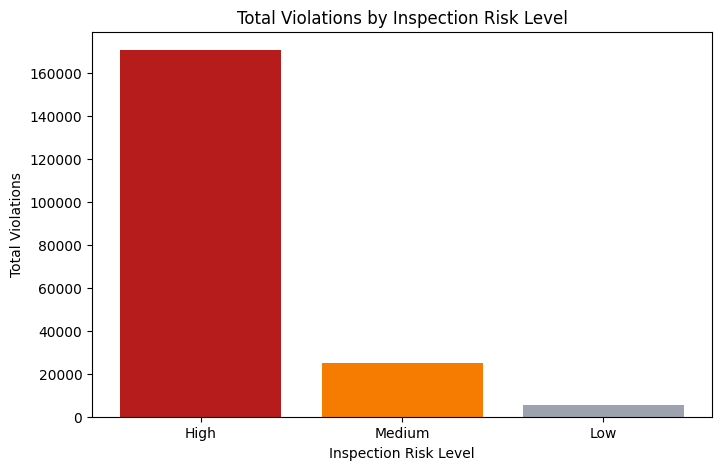

In [52]:
# Total violations by risk level
bar_colors = risk_summary_chart["inspection_risk_level"].map(risk_colors)

plt.figure(figsize=(8, 5))
plt.bar(
    risk_summary_chart["inspection_risk_level"],
    risk_summary_chart["total_violations"],
    color=bar_colors
)

plt.title("Total Violations by Inspection Risk Level")
plt.xlabel("Inspection Risk Level")
plt.ylabel("Total Violations")
plt.show()

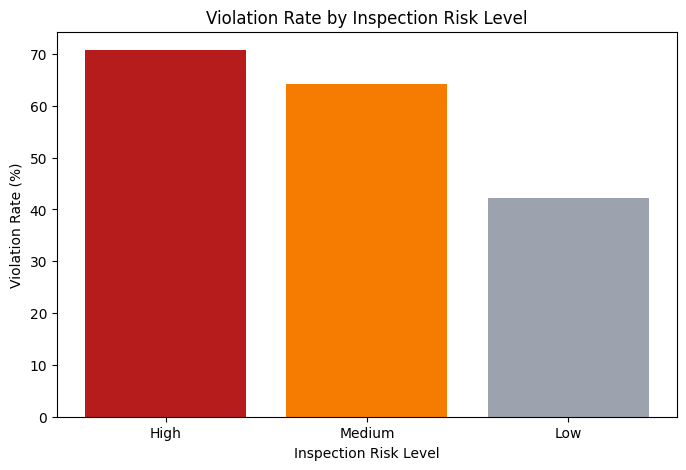

In [53]:
# Violation rate by risk level
bar_colors = risk_summary_chart["inspection_risk_level"].map(risk_colors)

plt.figure(figsize=(8, 5))
plt.bar(
    risk_summary_chart["inspection_risk_level"],
    risk_summary_chart["violation_rate"],
    color=bar_colors
)

plt.title("Violation Rate by Inspection Risk Level")
plt.xlabel("Inspection Risk Level")
plt.ylabel("Violation Rate (%)")
plt.show()

High-risk inspections had the highest total number of violations and the highest violation rate. This suggests that inspection risk level is meaningfully connected to violation patterns. Reviewing both total violations and violation rate helps separate overall issue volume from proportional risk.

### 5.7 Monthly Inspection Trend

I analyzed inspection volume by month to understand how inspection activity changed over time.

In [54]:
# Create monthly inspection summary
monthly_summary = df_clean.groupby("inspection_year_month").agg(
    total_inspections=("inspection_id", "count"),
    failed_inspections=("failed_flag", "sum")
).reset_index()

monthly_summary["fail_rate"] = (
    monthly_summary["failed_inspections"] / monthly_summary["total_inspections"] * 100
).round(2)

monthly_summary = monthly_summary.sort_values("inspection_year_month")

monthly_summary.head()

,inspection_year_month,total_inspections,failed_inspections,fail_rate
0,2023-01,1356,286,21.09
1,2023-02,1368,286,20.91
2,2023-03,1653,345,20.87
3,2023-04,1587,335,21.11
4,2023-05,1435,299,20.84


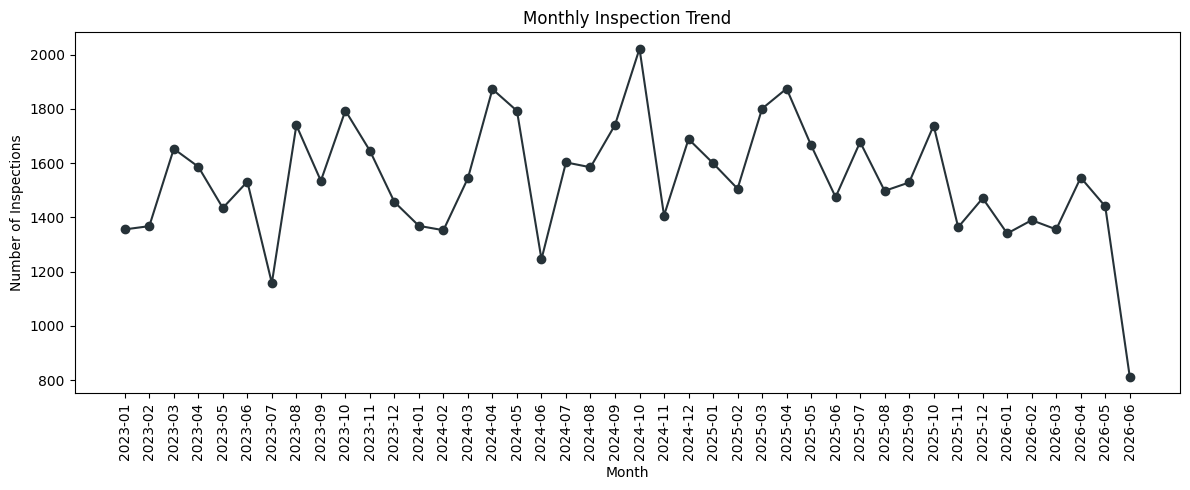

In [55]:
# Monthly inspection trend chart

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_summary["inspection_year_month"],
    monthly_summary["total_inspections"],
    marker="o",
    color=colors["dark"]
)
plt.title("Monthly Inspection Trend")
plt.xlabel("Month")
plt.ylabel("Number of Inspections")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### 5.8 Monthly Fail Rate Trend

I analyzed the monthly fail rate to understand whether non-compliance changed over time, regardless of the number of inspections completed each month.

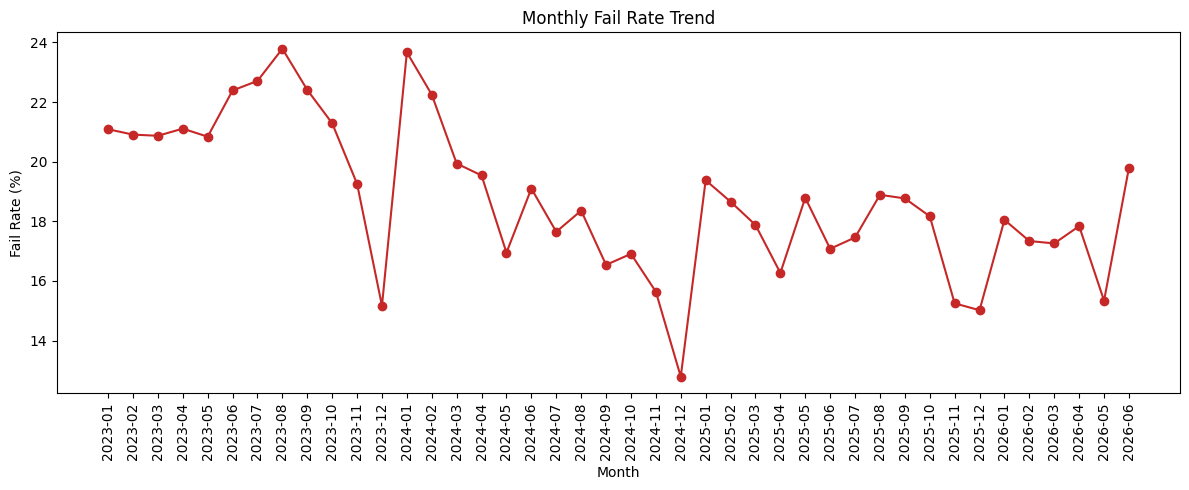

In [56]:
# Monthly fail rate trend
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary["inspection_year_month"],
    monthly_summary["fail_rate"],
    marker="o",
    color=colors["red"]
)

plt.title("Monthly Fail Rate Trend")
plt.xlabel("Month")
plt.ylabel("Fail Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

The monthly fail rate shows how non-compliance changed over time as a percentage of total inspections. This is useful because it separates compliance performance from inspection volume. Some months may have fewer inspections, so reviewing fail rate alongside inspection volume gives a clearer picture.

## 6. Priority Facilities & Corrective Action Scoring

In this section, I moved from general trends to facility-level analysis. The goal is to identify facilities that may need closer review based on failed inspections, violation volume, fail rate, and inspection history.

### 6.1 Create Facility-Level Summary

I summarized the data at the facility level to identify locations with repeated inspections, failed inspections, and high violation counts.

In [57]:
# Create facility-level summary
facility_summary = df_clean.groupby([
    "dba_name",
    "address",
    "zip",
    "food_business_group",
    "inspection_risk_level"
]).agg(
    total_inspections=("inspection_id", "count"),
    failed_inspections=("failed_flag", "sum"),
    total_violations=("violation_count", "sum")
).reset_index()

facility_summary.head()

,dba_name,address,zip,food_business_group,inspection_risk_level,total_inspections,failed_inspections,total_violations
0,#1 CHOP SUEY,4307 W IRVING PARK RD,60641.0,Restaurants & Food Service,High,8,3,32
1,"#1 CHOP SUEY RESTAURANT, INC",7342 S STONY ISLAND AVE,60649.0,Restaurants & Food Service,High,5,1,22
2,"#1 DELI, INC",6901 S NORMAL BLVD,60621.0,Retail & Specialty Food Stores,High,2,0,0
3,'C' A CATERING AND EVENT COMPANY,4300-4304 N CENTRAL AVE,60634.0,Restaurants & Food Service,High,11,1,5
4,'LAINE'S BAKE SHOP,11057 S HOMEWOOD AVE,60643.0,"Bakeries, Sweets & Desserts",Medium,1,0,0


In [58]:
# Calculate facility-level rates
facility_summary["fail_rate"] = (
    facility_summary["failed_inspections"] / facility_summary["total_inspections"] * 100
).round(2)

facility_summary["avg_violations_per_inspection"] = (
    facility_summary["total_violations"] / facility_summary["total_inspections"]
).round(2)

facility_summary.head()

,dba_name,address,zip,food_business_group,inspection_risk_level,total_inspections,failed_inspections,total_violations,fail_rate,avg_violations_per_inspection
0,#1 CHOP SUEY,4307 W IRVING PARK RD,60641.0,Restaurants & Food Service,High,8,3,32,37.50,4.00
1,"#1 CHOP SUEY RESTAURANT, INC",7342 S STONY ISLAND AVE,60649.0,Restaurants & Food Service,High,5,1,22,20.00,4.40
2,"#1 DELI, INC",6901 S NORMAL BLVD,60621.0,Retail & Specialty Food Stores,High,2,0,0,0.00,0.00
3,'C' A CATERING AND EVENT COMPANY,4300-4304 N CENTRAL AVE,60634.0,Restaurants & Food Service,High,11,1,5,9.09,0.45
4,'LAINE'S BAKE SHOP,11057 S HOMEWOOD AVE,60643.0,"Bakeries, Sweets & Desserts",Medium,1,0,0,0.00,0.00


This facility-level summary helps identify repeated issues at specific locations rather than only looking at broad business groups.

### 6.2 Create Priority Facilities Table

To make the facility-level analysis more useful, I filtered the data to keep facilities with enough inspection history. This helps avoid ranking facilities based on only one or two inspections.

In [59]:
# Keep facilities with enough inspection records for meaningful comparison
priority_facilities = facility_summary[
    facility_summary["total_inspections"] >= 5
].copy()

priority_facilities.head()

,dba_name,address,zip,food_business_group,inspection_risk_level,total_inspections,failed_inspections,total_violations,fail_rate,avg_violations_per_inspection
0,#1 CHOP SUEY,4307 W IRVING PARK RD,60641.0,Restaurants & Food Service,High,8,3,32,37.50,4.00
1,"#1 CHOP SUEY RESTAURANT, INC",7342 S STONY ISLAND AVE,60649.0,Restaurants & Food Service,High,5,1,22,20.00,4.40
3,'C' A CATERING AND EVENT COMPANY,4300-4304 N CENTRAL AVE,60634.0,Restaurants & Food Service,High,11,1,5,9.09,0.45
6,1 KARACHI CHAAT HOUSE,2301 W DEVON AVE,60659.0,Restaurants & Food Service,High,6,1,17,16.67,2.83
9,1 STOP MARKET & GRILL,2132-2134 W WASHINGTON BLVD,60612.0,Retail & Specialty Food Stores,High,5,2,22,40.00,4.40


In [60]:
# Sort facilities by total violations
priority_facilities = priority_facilities.sort_values(
    by="total_violations",
    ascending=False
)

priority_facilities.head(10)

,dba_name,address,zip,food_business_group,inspection_risk_level,total_inspections,failed_inspections,total_violations,fail_rate,avg_violations_per_inspection
7448,JERK MAN,7723 S STATE ST,60619.0,Restaurants & Food Service,High,29,13,240,44.83,8.28
6912,HOTEL LINCOLN,1816 N CLARK ST,60614.0,Restaurants & Food Service,High,18,9,167,50.00,9.28
4665,EATALY,43 E OHIO ST,60611.0,Restaurants & Food Service,High,19,9,145,47.37,7.63
14869,TAQUERIA EL RANCHITO,2829 N MILWAUKEE AVE,60618.0,Restaurants & Food Service,High,14,4,144,28.57,10.29
13079,SEASHELL,3944 W ROOSEVELT RD,60624.0,Restaurants & Food Service,Medium,19,9,139,47.37,7.32
6841,HONEY BERRY PANCAKES & CAFE STATE STREET,901 S STATE ST,60605.0,Restaurants & Food Service,High,18,11,126,61.11,7.00
2477,CAPTAIN HOOKS FISH & CHICKEN,8554 S COTTAGE GROVE AVE,60619.0,Restaurants & Food Service,High,15,2,119,13.33,7.93
9100,LOCAL MARKET,2101 E 71ST ST,60649.0,Retail & Specialty Food Stores,High,17,4,119,23.53,7.00
2495,CARIBBEAN JERK PLACE II,120 W 87TH ST,60620.0,Restaurants & Food Service,High,8,3,119,37.50,14.88
13090,SEE THRU CHINESE KITCHEN,10939 S WESTERN AVE,60643.0,Restaurants & Food Service,High,13,4,117,30.77,9.00


In [61]:
#  readable priority facilities table
priority_facilities_display = priority_facilities[[
    "dba_name",
    "address",
    "zip",
    "food_business_group",
    "inspection_risk_level",
    "total_inspections",
    "failed_inspections",
    "fail_rate",
    "total_violations",
    "avg_violations_per_inspection"
]].head(10).rename(columns={
    "dba_name": "Facility",
    "address": "Address",
    "zip": "ZIP",
    "food_business_group": "Food Business Group",
    "inspection_risk_level": "Risk Level",
    "total_inspections": "Total Inspections",
    "failed_inspections": "Failed Inspections",
    "fail_rate": "Fail Rate (%)",
    "total_violations": "Total Violations",
    "avg_violations_per_inspection": "Avg. Violations per Inspection"
})

priority_facilities_display

,Facility,Address,ZIP,Food Business Group,Risk Level,Total Inspections,Failed Inspections,Fail Rate (%),Total Violations,Avg. Violations per Inspection
7448,JERK MAN,7723 S STATE ST,60619.0,Restaurants & Food Service,High,29,13,44.83,240,8.28
6912,HOTEL LINCOLN,1816 N CLARK ST,60614.0,Restaurants & Food Service,High,18,9,50.00,167,9.28
4665,EATALY,43 E OHIO ST,60611.0,Restaurants & Food Service,High,19,9,47.37,145,7.63
14869,TAQUERIA EL RANCHITO,2829 N MILWAUKEE AVE,60618.0,Restaurants & Food Service,High,14,4,28.57,144,10.29
13079,SEASHELL,3944 W ROOSEVELT RD,60624.0,Restaurants & Food Service,Medium,19,9,47.37,139,7.32
6841,HONEY BERRY PANCAKES & CAFE STATE STREET,901 S STATE ST,60605.0,Restaurants & Food Service,High,18,11,61.11,126,7.00
2477,CAPTAIN HOOKS FISH & CHICKEN,8554 S COTTAGE GROVE AVE,60619.0,Restaurants & Food Service,High,15,2,13.33,119,7.93
9100,LOCAL MARKET,2101 E 71ST ST,60649.0,Retail & Specialty Food Stores,High,17,4,23.53,119,7.00
2495,CARIBBEAN JERK PLACE II,120 W 87TH ST,60620.0,Restaurants & Food Service,High,8,3,37.50,119,14.88
13090,SEE THRU CHINESE KITCHEN,10939 S WESTERN AVE,60643.0,Restaurants & Food Service,High,13,4,30.77,117,9.00


In [62]:
priority_facilities_display.style.hide(axis="index").format({
    "Fail Rate (%)": "{:.2f}",
    "Avg. Violations per Inspection": "{:.2f}"
})

Facility,Address,ZIP,Food Business Group,Risk Level,Total Inspections,Failed Inspections,Fail Rate (%),Total Violations,Avg. Violations per Inspection
JERK MAN,7723 S STATE ST,60619.000000,Restaurants & Food Service,High,29,13,44.83,240,8.28
HOTEL LINCOLN,1816 N CLARK ST,60614.000000,Restaurants & Food Service,High,18,9,50.00,167,9.28
EATALY,43 E OHIO ST,60611.000000,Restaurants & Food Service,High,19,9,47.37,145,7.63
TAQUERIA EL RANCHITO,2829 N MILWAUKEE AVE,60618.000000,Restaurants & Food Service,High,14,4,28.57,144,10.29
SEASHELL,3944 W ROOSEVELT RD,60624.000000,Restaurants & Food Service,Medium,19,9,47.37,139,7.32
HONEY BERRY PANCAKES & CAFE STATE STREET,901 S STATE ST,60605.000000,Restaurants & Food Service,High,18,11,61.11,126,7.00
CAPTAIN HOOKS FISH & CHICKEN,8554 S COTTAGE GROVE AVE,60619.000000,Restaurants & Food Service,High,15,2,13.33,119,7.93
LOCAL MARKET,2101 E 71ST ST,60649.000000,Retail & Specialty Food Stores,High,17,4,23.53,119,7.00
CARIBBEAN JERK PLACE II,120 W 87TH ST,60620.000000,Restaurants & Food Service,High,8,3,37.50,119,14.88
SEE THRU CHINESE KITCHEN,10939 S WESTERN AVE,60643.000000,Restaurants & Food Service,High,13,4,30.77,117,9.00


The priority facilities table highlights locations with repeated inspection history and higher violation volume. Filtering for facilities with at least five inspections makes the comparison more reliable and reduces the chance of overreacting to one-time inspection results.

### 6.3 Create Scoring Rules

I created a simple rule-based scoring system to prioritize facilities for follow-up. The score is based on inspection failure rate, total violations, average violations per inspection, risk level, and inspection history.

In [63]:
# Create priority scoring rules table
scoring_rules = pd.DataFrame({
    "Condition": [
        "Fail rate >= 25%",
        "Total violations >= 100",
        "Average violations per inspection >= 5",
        "Inspection risk level = High",
        "Total inspections >= 10"
    ],
    "Points Added": [3, 3, 2, 2, 1]
})

scoring_rules

,Condition,Points Added
0,Fail rate >= 25%,3
1,Total violations >= 100,3
2,Average violations per inspection >= 5,2
3,Inspection risk level = High,2
4,Total inspections >= 10,1


The scoring rules are simple and transparent. They are not intended to create a predictive model, but to create a practical prioritization method that can support corrective-action planning.

In [64]:
# Priority level reference table
priority_rules = pd.DataFrame({
    "Priority Level": ["High Priority", "Medium Priority", "Low Priority"],
    "Priority Score Range": ["7 or more", "4 to 6", "0 to 3"],
    "Meaning": [
        "Higher corrective-action concern and should be prioritized for follow-up.",
        "Moderate corrective-action concern and may need review.",
        "Lower corrective-action concern based on the scoring rules."
    ]
})

# Add color coding to priority level table
def color_priority_level(value):
    if value == "High Priority":
        return f"background-color: {priority_colors['High Priority']}; color: white"
    elif value == "Medium Priority":
        return f"background-color: {priority_colors['Medium Priority']}; color: black"
    elif value == "Low Priority":
        return f"background-color: {priority_colors['Low Priority']}; color: black"
    else:
        return ""

priority_rules.style.hide(axis="index").map(
    color_priority_level,
    subset=["Priority Level"]
)

Priority Level,Priority Score Range,Meaning
High Priority,7 or more,Higher corrective-action concern and should be prioritized for follow-up.
Medium Priority,4 to 6,Moderate corrective-action concern and may need review.
Low Priority,0 to 3,Lower corrective-action concern based on the scoring rules.


### 6.4 Apply Priority Score

I applied the scoring rules to each facility to calculate a priority score. Facilities with higher scores may need closer review or follow-up action.


In [65]:
# Create a copy of the priority facilities table for scoring
facility_risk_score = priority_facilities.copy()

In [66]:
# Start with a score of 0
facility_risk_score["priority_score"] = 0

# Add points based on risk factors
facility_risk_score.loc[facility_risk_score["fail_rate"] >= 25, "priority_score"] += 3
facility_risk_score.loc[facility_risk_score["total_violations"] >= 100, "priority_score"] += 3
facility_risk_score.loc[facility_risk_score["avg_violations_per_inspection"] >= 5, "priority_score"] += 2
facility_risk_score.loc[facility_risk_score["inspection_risk_level"] == "High", "priority_score"] += 2
facility_risk_score.loc[facility_risk_score["total_inspections"] >= 10, "priority_score"] += 1

In [67]:
# priority level based on the score
facility_risk_score["priority_level"] = "Low Priority"

facility_risk_score.loc[
    facility_risk_score["priority_score"] >= 4,
    "priority_level"
] = "Medium Priority"

facility_risk_score.loc[
    facility_risk_score["priority_score"] >= 7,
    "priority_level"
] = "High Priority"

In [68]:
# Sort facilities by priority score and total violations
facility_risk_score = facility_risk_score.sort_values(
    by=["priority_score", "total_violations"],
    ascending=False
)

In [69]:
facility_risk_score[["dba_name", "priority_score", "priority_level"]].head()

,dba_name,priority_score,priority_level
7448,JERK MAN,11,High Priority
6912,HOTEL LINCOLN,11,High Priority
4665,EATALY,11,High Priority
14869,TAQUERIA EL RANCHITO,11,High Priority
6841,HONEY BERRY PANCAKES & CAFE STATE STREET,11,High Priority


### 6.5 Top Priority Facilities

I created a final priority table to show the facilities with the highest priority scores and highest violation volume. This table is designed to support corrective-action planning.


In [70]:
# Create final top priority facilities table
top_priority_table_display = facility_risk_score[[
    "dba_name",
    "food_business_group",
    "inspection_risk_level",
    "total_inspections",
    "failed_inspections",
    "fail_rate",
    "total_violations",
    "avg_violations_per_inspection",
    "priority_score",
    "priority_level"
]].head(10).rename(columns={
    "dba_name": "Facility",
    "food_business_group": "Food Business Group",
    "inspection_risk_level": "Risk Level",
    "total_inspections": "Total Inspections",
    "failed_inspections": "Failed Inspections",
    "fail_rate": "Fail Rate (%)",
    "total_violations": "Total Violations",
    "avg_violations_per_inspection": "Avg. Violations per Inspection",
    "priority_score": "Priority Score",
    "priority_level": "Priority Level"
})

In [71]:
# Display final table with color-coded priority level
top_priority_table_display.style.hide(axis="index").format({
    "Fail Rate (%)": "{:.2f}",
    "Avg. Violations per Inspection": "{:.2f}",
    "Priority Score": "{:.0f}"
}).map(
    color_priority_level,
    subset=["Priority Level"]
)

Facility,Food Business Group,Risk Level,Total Inspections,Failed Inspections,Fail Rate (%),Total Violations,Avg. Violations per Inspection,Priority Score,Priority Level
JERK MAN,Restaurants & Food Service,High,29,13,44.83,240,8.28,11,High Priority
HOTEL LINCOLN,Restaurants & Food Service,High,18,9,50.00,167,9.28,11,High Priority
EATALY,Restaurants & Food Service,High,19,9,47.37,145,7.63,11,High Priority
TAQUERIA EL RANCHITO,Restaurants & Food Service,High,14,4,28.57,144,10.29,11,High Priority
HONEY BERRY PANCAKES & CAFE STATE STREET,Restaurants & Food Service,High,18,11,61.11,126,7.00,11,High Priority
SEE THRU CHINESE KITCHEN,Restaurants & Food Service,High,13,4,30.77,117,9.00,11,High Priority
MARIANO'S FRESH MARKET #8503,Retail & Specialty Food Stores,High,13,5,38.46,115,8.85,11,High Priority
SOUTH SHORE FOOD MART INC.,Retail & Specialty Food Stores,High,15,9,60.00,115,7.67,11,High Priority
IMPERIAL RESTAURANT,Restaurants & Food Service,High,13,7,53.85,113,8.69,11,High Priority
JEWEL FOOD STORE #0092,Retail & Specialty Food Stores,High,15,5,33.33,112,7.47,11,High Priority


### 6.6 Facilities by Priority Level

I summarized facilities by priority level to understand how many locations fall under high, medium, and low corrective-action priority.

In [72]:
# Count facilities by priority level
priority_level_summary = facility_risk_score["priority_level"].value_counts().reset_index()

priority_level_summary.columns = ["priority_level", "facility_count"]

# Sort priority levels in a logical order
priority_order = {
    "High Priority": 1,
    "Medium Priority": 2,
    "Low Priority": 3
}

priority_level_summary["sort_order"] = priority_level_summary["priority_level"].map(priority_order)

priority_level_summary = priority_level_summary.sort_values("sort_order")

# Create a readable display table
priority_level_summary_display = priority_level_summary.drop(columns="sort_order").rename(columns={
    "priority_level": "Priority Level",
    "facility_count": "Facility Count"
})

priority_level_summary_display

,Priority Level,Facility Count
2,High Priority,839
1,Medium Priority,1867
0,Low Priority,3038


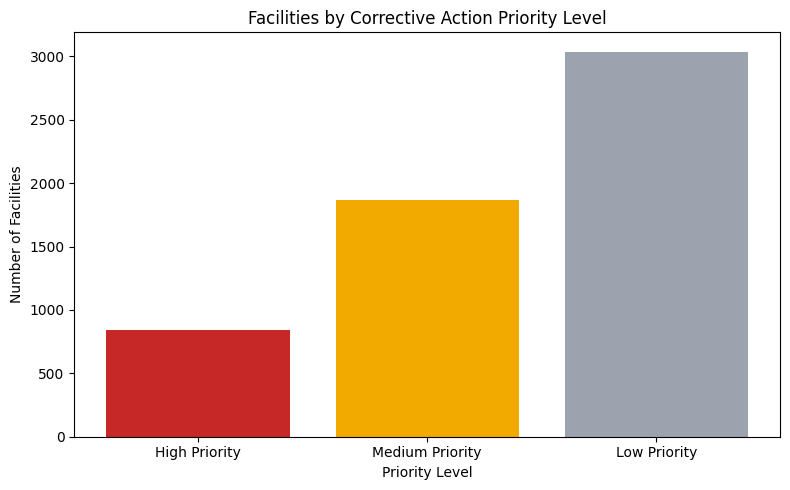

In [73]:
# Facilities by priority level chart
bar_colors = priority_level_summary["priority_level"].map(priority_colors)

plt.figure(figsize=(8, 5))

plt.bar(
    priority_level_summary["priority_level"],
    priority_level_summary["facility_count"],
    color=bar_colors
)

plt.title("Facilities by Corrective Action Priority Level")
plt.xlabel("Priority Level")
plt.ylabel("Number of Facilities")

plt.tight_layout()
plt.show()

Most facilities were classified as low or medium priority, while a smaller group was classified as high priority. This helps narrow the focus for corrective-action planning by identifying which facilities may need closer review first.

### 6.7 Top Priority Facilities by Total Violations

I visualized the top priority facilities by total violation count to show which locations had the highest issue volume among the highest-priority facilities.

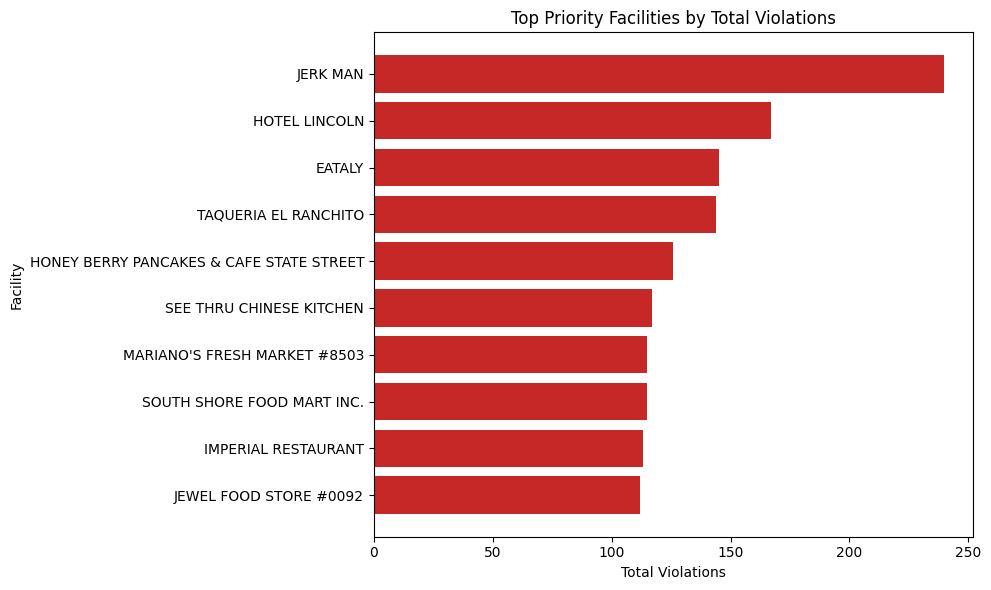

In [74]:
# Top priority facilities by total violations
top_scored_facilities = facility_risk_score.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_scored_facilities["dba_name"],
    top_scored_facilities["total_violations"],
    color=colors["red"]
)

plt.gca().invert_yaxis()
plt.title("Top Priority Facilities by Total Violations")
plt.xlabel("Total Violations")
plt.ylabel("Facility")

plt.tight_layout()
plt.show()

The chart shows the highest-priority facilities ranked by total violations. Since many of these facilities have the same priority score, total violations helps further distinguish which locations may need to be reviewed first.

## 7. Conclusion

This project used Python to analyze food inspection data and identify patterns related to inspection outcomes, violations, risk levels, and corrective-action priorities.

The analysis showed that restaurants and food service businesses represented the largest share of inspections and failed inspections. However, reviewing fail rates helped provide a more proportional view of non-compliance across different food business groups.

High-risk inspections had the highest total violations and the highest violation rate, which suggests that inspection risk level is meaningfully connected to violation patterns.

The facility-level priority analysis helped move the project from general reporting into action planning. By creating a simple rule-based priority score, I was able to identify facilities that may require closer review based on fail rate, total violations, average violations per inspection, risk level, and inspection history.

This project is not intended to be a predictive model. Instead, it is a practical beginner-friendly Python analysis that demonstrates data cleaning, feature engineering, exploratory analysis, visualization, and simple scoring logic in a food safety context.